In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("1 - Sample - Superstore.csv", encoding='windows-1252')

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [7]:
df['Year'] =  df['Order Date'].dt.year

In [8]:
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,2016
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,2016


## Line Chart

In [9]:
daily_sales = df.groupby('Order Date')['Sales'].sum()
daily_sales

Order Date
2014-01-03      16.4480
2014-01-04     288.0600
2014-01-05      19.5360
2014-01-06    4407.1000
2014-01-07      87.1580
                ...    
2017-12-26     814.5940
2017-12-27     177.6360
2017-12-28    1657.3508
2017-12-29    2915.5340
2017-12-30     713.7900
Name: Sales, Length: 1237, dtype: float64

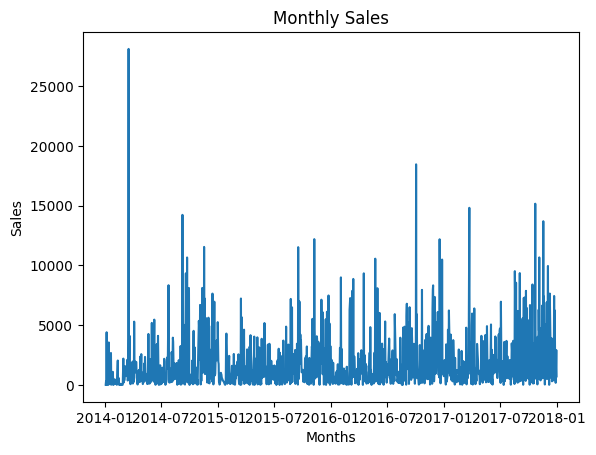

In [15]:
plt.plot(daily_sales.index, daily_sales.values)
plt.title("Monthly Sales")
plt.xlabel("Months")
plt.ylabel("Sales")
plt.show()

In [11]:
yearly_sales = df.groupby('Year')['Sales'].sum()
yearly_sales

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

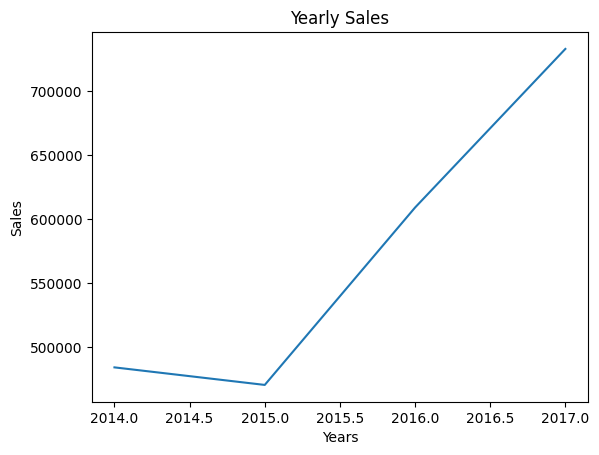

In [18]:
plt.plot(yearly_sales.index, yearly_sales.values)
plt.title("Yearly Sales")
plt.xlabel("Years")
plt.ylabel("Sales")
plt.show()

In [17]:
# city wise profit
city_profit = df.groupby('City')['Profit'].sum()
city_profit

City
Aberdeen          6.6300
Abilene          -3.7584
Akron          -186.6356
Albuquerque     634.0881
Alexandria      318.6183
                 ...    
Woonsocket       78.6791
Yonkers        2767.7557
York           -102.1692
Yucaipa          13.2080
Yuma           -465.9909
Name: Profit, Length: 531, dtype: float64

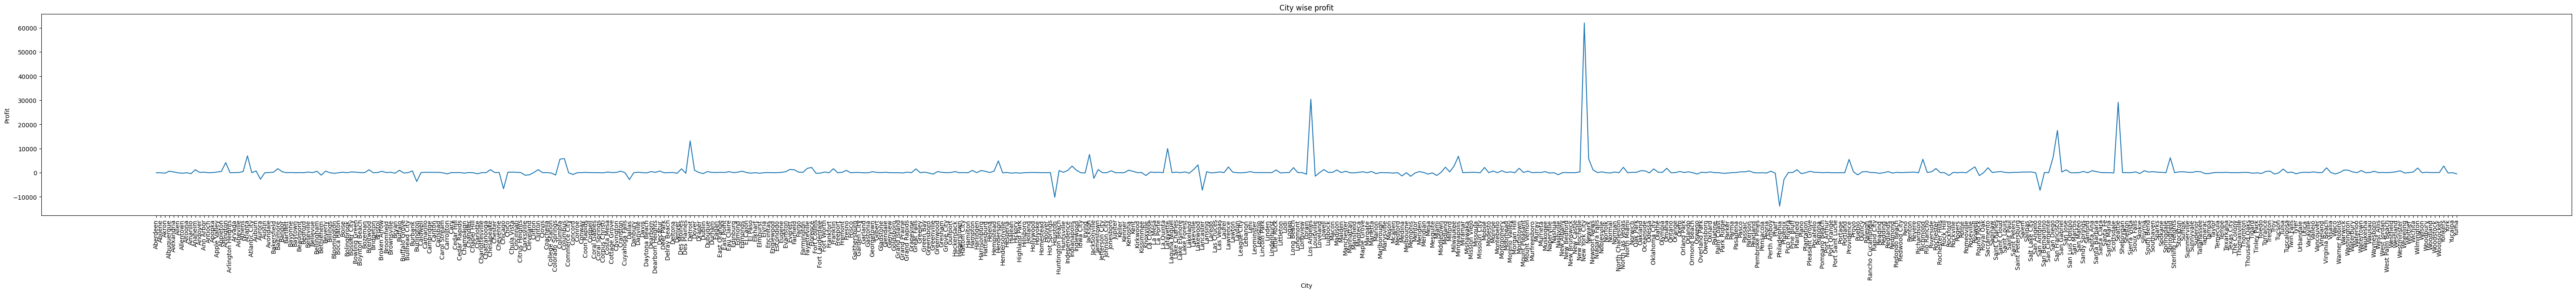

In [39]:
plt.figure(figsize=(75,6))
plt.plot(city_profit.index, city_profit.values)
plt.title("City wise profit")
plt.xticks(rotation=90)
plt.xlabel("City")
plt.ylabel("Profit")
plt.show()

## Bar Chart

In [ ]:
# state wise profit
state_profit = df.groupby('State')['Profit'].sum()
state_profit

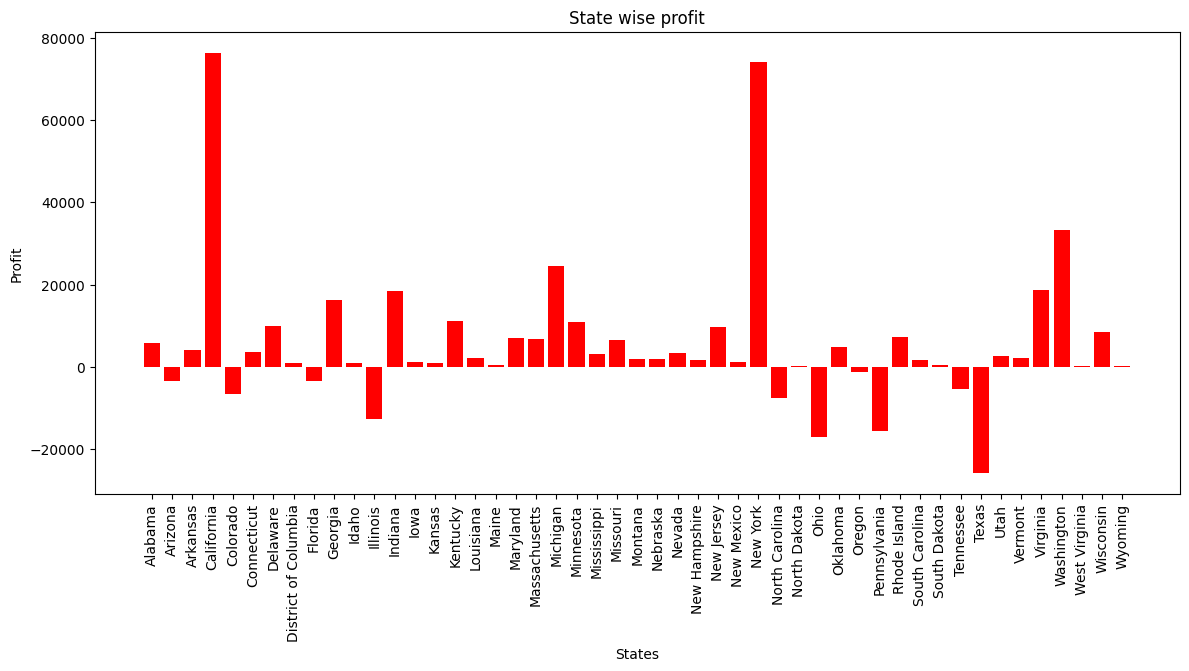

In [33]:
plt.figure(figsize=(14,6))
plt.bar(state_profit.index, state_profit.values, color='red')
plt.title("State wise profit")
plt.xticks(rotation=90)
plt.xlabel("States")
plt.ylabel("Profit")
plt.show()

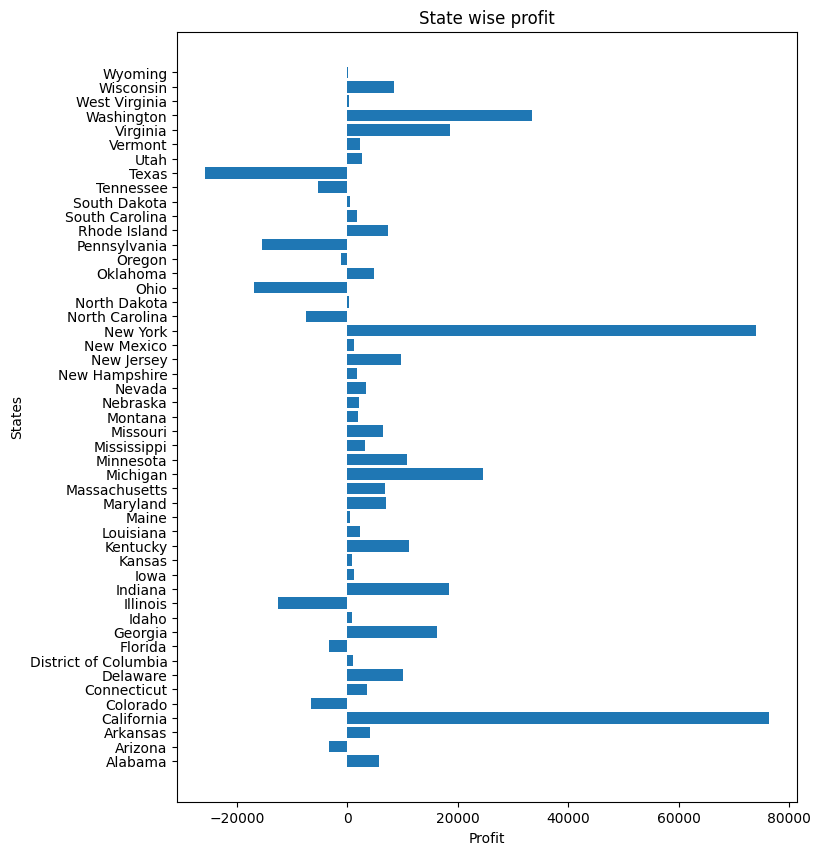

In [36]:
plt.figure(figsize=(8,10))
plt.barh(state_profit.index, state_profit.values)
plt.title("State wise profit")
plt.xlabel("Profit")
plt.ylabel("States")
plt.show()